In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import tensorflow as tf
from tensorflow.keras import layers, models,datasets

In [12]:
# load dataset
(x_train,y_train),(x_test,y_test)=datasets.mnist.load_data()

In [13]:
#normalise
x_train=x_train/255.0
x_test=x_test/255.0

In [14]:
x_train.shape

(60000, 28, 28)

In [15]:
# # adding channel
x_train=x_train[...,tf.newaxis]
x_test=x_test[...,tf.newaxis]

In [17]:
x_train.shape

(60000, 28, 28, 1)

In [18]:
model=models.Sequential([
    layers.Conv2D(32,(3,3),activation="relu",input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64,(3,3)),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(64,activation="relu"),
    layers.Dense(10,activation="softmax")
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [22]:
model.compile(optimizer="adam",loss="sparse_categorical_crossentropy",metrics=["accuracy"])


In [47]:
history=model.fit(x_train,y_train,epochs=10,batch_size=64,validation_split=0.1)

Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9990 - loss: 0.0033 - val_accuracy: 0.9902 - val_loss: 0.0645
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9989 - loss: 0.0035 - val_accuracy: 0.9893 - val_loss: 0.0762
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9989 - loss: 0.0032 - val_accuracy: 0.9893 - val_loss: 0.0778
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9988 - loss: 0.0042 - val_accuracy: 0.9902 - val_loss: 0.0733
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9994 - loss: 0.0022 - val_accuracy: 0.9907 - val_loss: 0.0845
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9990 - loss: 0.0038 - val_accuracy: 0.9907 - val_loss: 0.0704
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9993 - loss: 0.0021 - val_accuracy: 0.9885 - val_loss: 0.0790
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9996 - loss: 0.0014 - val_accuracy: 0.

In [48]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 365,792 (1.40 MB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 243,862 (952.59 KB)

In [49]:
test_loss, test_acc = model.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9903 - loss: 0.0658


In [50]:
print(test_acc)

0.9902999997138977


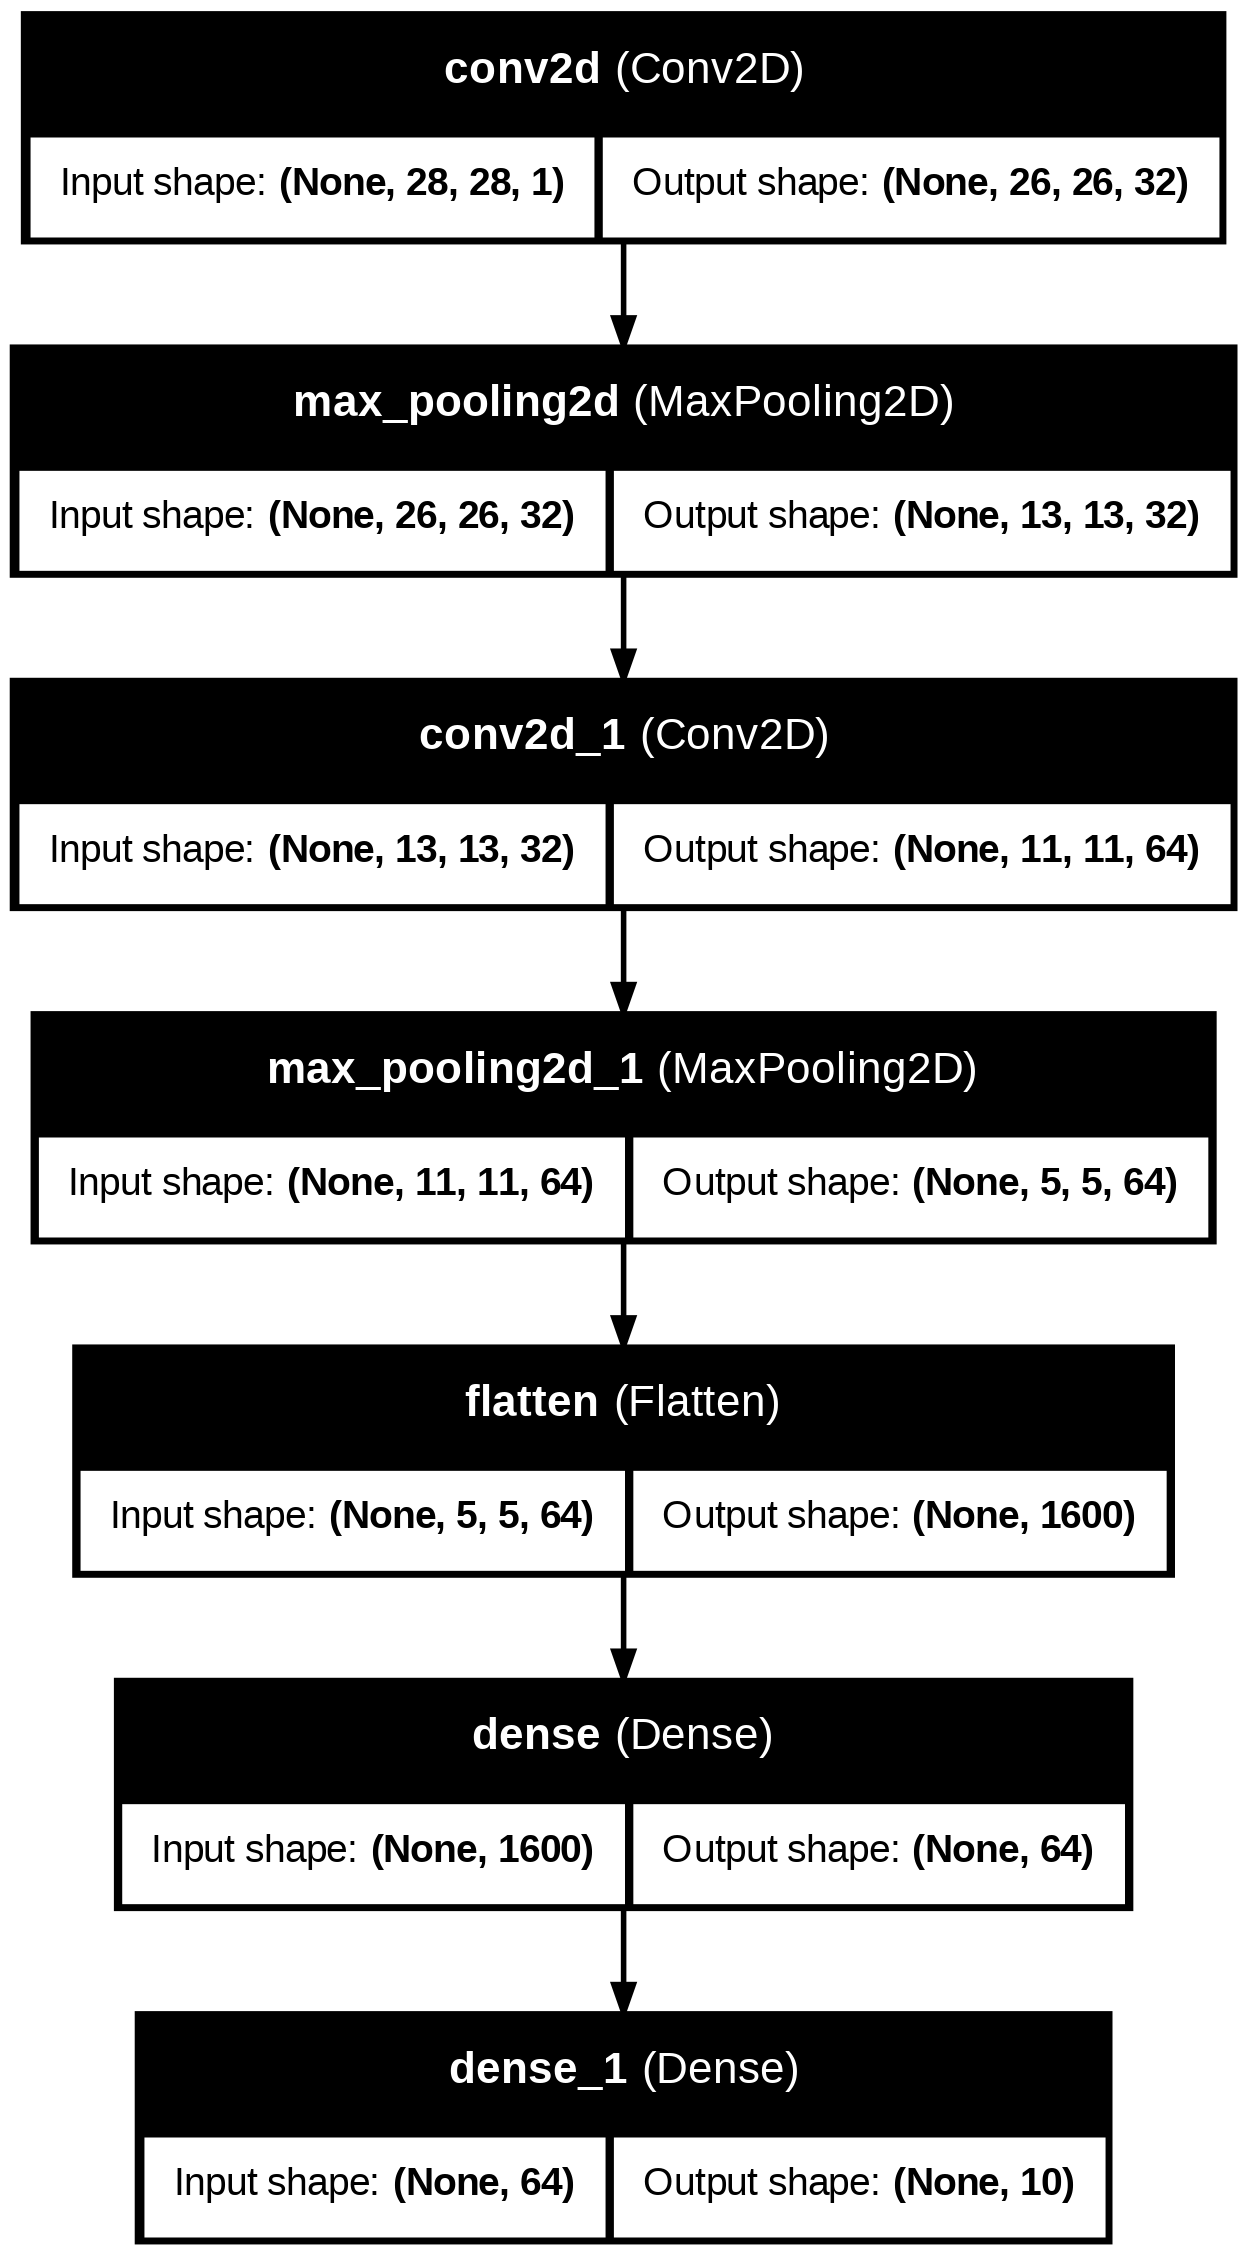

In [51]:
from tensorflow.keras.utils import plot_model
plot_model(model,show_shapes=True,show_layer_names=True)

In [52]:
print(type(history))

<class 'keras.src.callbacks.history.History'>


In [54]:
print(history.history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


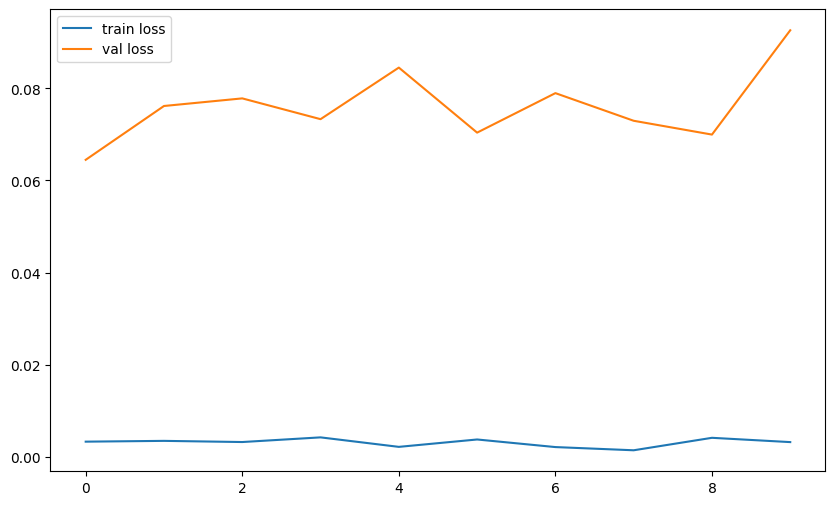

In [55]:
from matplotlib import figure
fig,ax=plt.subplots(figsize=(10,6))
ax.plot(history.history["loss"],label="train loss")
ax.plot(history.history["val_loss"],label="val loss")
ax.legend()
plt.show()

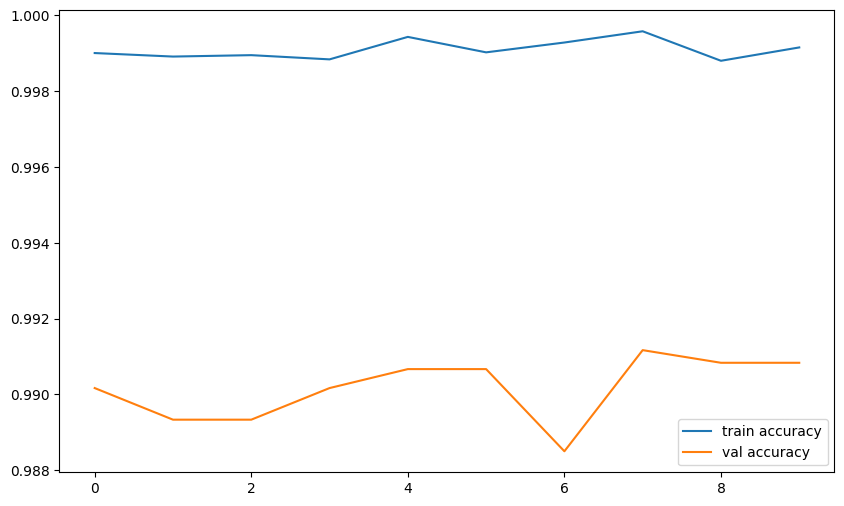

In [56]:
from matplotlib import figure
fig,ax=plt.subplots(figsize=(10,6))
ax.plot(history.history["accuracy"],label="train accuracy")
ax.plot(history.history["val_accuracy"],label="val accuracy")
ax.legend()
plt.show()

In [57]:
model.save("mnist_model_tf.h5")

In [59]:
tf_model=tf.keras.models.load_model("mnist_model_tf.h5")


In [4]:
import numpy as np
def predict_image(image):
  image=image.convert("L")
  image=image.resize((28,28))
  image=np.array(image)
  image=255-image
  image=image/255.0
  image=image.reshape(1,28,28,1)
  prediction=model.predict(image,verbose=0)
  return {str(i):float(prediction[0][i]) for i in range(10)}

In [2]:
import gradio as gr

In [5]:
Demo=gr.Interface(
    fn=predict_image,
    inputs=gr.Image(type="pil"),
    outputs=gr.Label(num_top_classes=3),
    title="MNIST DIGIT CLASSIFIER",
    description="Upload a handwritten digit image."
)
# Demo.launch()

Pytorch

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

In [8]:
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [9]:
transform = transforms.ToTensor()

In [10]:
train_dataset=datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)
test_dataset=datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.6MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 492kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.64MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 13.5MB/s]


In [19]:
train_loader=DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)
test_loader=DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

In [27]:
class CNN(nn.Module):
  def __init__(self):
    super().__init__()
    self.conv=nn.Sequential(
    nn.Conv2d(1,32,kernel_size=3,padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2,2),
    nn.Conv2d(32,64,kernel_size=3,padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2,2)
    )
    self.fc=nn.Sequential(
         nn.Linear(
             64*7*7,128
         ),
         nn.ReLU(),
         nn.Linear(128,10)
    )
  def forward(self,x):
    x=self.conv(x)
    x=x.view(x.size(0),-1)
    x=self.fc(x)
    return x
model_2=CNN().to(device)

In [28]:
criterion=nn.CrossEntropyLoss()
optimizer=optim.Adam(model_2.parameters(),lr=0.001)
for epoch in range(10):
  model_2.train()
  running_loss=0
  for images,labels in train_loader:
    images,labels=images.to(device),labels.to(device)
    optimizer.zero_grad() # erase old gradients
    outputs=model_2(images)
    loss=criterion(outputs,labels)
    loss.backward() # calculate new gradients
    optimizer.step() # update weights
    running_loss+=loss.item()
  print(f"Epoch{epoch+1}:loss={running_loss/len(train_loader):4f}")

Epoch1:loss=0.177578
Epoch2:loss=0.050292
Epoch3:loss=0.034029
Epoch4:loss=0.024440
Epoch5:loss=0.018897
Epoch6:loss=0.015195
Epoch7:loss=0.012495
Epoch8:loss=0.009143
Epoch9:loss=0.007918
Epoch10:loss=0.007969


In [34]:
# evaluation
model_2.eval()

CNN(
  (conv): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc): Sequential(
    (0): Linear(in_features=3136, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=10, bias=True)
  )
)

In [38]:
model_2.eval()
correct=0
total=0
with torch.no_grad():
  for images,labels in test_loader:
    images,labels=images.to(device),labels.to(device)
    output=model_2(images)
    _,predicted=torch.max(output,1)
    total+=labels.size(0)
    correct+=(predicted==labels).sum().item()
print(f"test accuracy{100*correct/total:.2f}%")

test accuracy99.19%


In [40]:
torch.save(model_2.state_dict(), "MNIST_MODEL_PYTORCH.pt")

In [42]:
import numpy as np
from PIL import Image

def predict_image_pytorch(image: Image.Image):
    # Preprocess the image for PyTorch model
    image = image.convert("L") # Convert to grayscale
    image = image.resize((28, 28)) # Resize to 28x28
    image_np = np.array(image)
    image_np = 255 - image_np # Invert colors (MNIST is white digit on black background)
    image_np = image_np / 255.0 # Normalize to [0, 1]

    # Add batch and channel dimensions: (1, 1, 28, 28)
    image_tensor = torch.tensor(image_np, dtype=torch.float32).unsqueeze(0).unsqueeze(0)
    image_tensor = image_tensor.to(device) # Move to the correct device

    model_2.eval() # Set model to evaluation mode
    with torch.no_grad():
        outputs = model_2(image_tensor)

    probabilities = torch.softmax(outputs, dim=1)[0]

    # Convert to dictionary for Gradio Label output
    return {str(i): float(probabilities[i]) for i in range(10)}

# Create and launch Gradio Interface for PyTorch model
PyTorch_Demo = gr.Interface(
    fn=predict_image_pytorch,
    inputs=gr.Image(type="pil"),
    outputs=gr.Label(num_top_classes=3),
    title="PyTorch MNIST Digit Classifier",
    description="Upload a handwritten digit image for prediction using the PyTorch CNN model."
)

# PyTorch_Demo.launch()